# Transitive Inference — Base Case
Train a CNN on adjacent pairs, test on non-adjacent pairs.

In [ ]:
import os
from pathlib import Path
#put the directory of the folder that you want here!
os.chdir(Path("/mnt/smb/locker/abbott-locker/Luke/Mnist") / "Mnist v3") 
!pwd

/mnt/smb/locker/abbott-locker/Luke/Mnist/Mnist v3


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from TransitiveTrainDataset import TransitiveTrainDataset
from TransitiveTestDataset import TransitiveTestDataset

## Parameters

In [11]:
# Training
BATCH_SIZE = 64
TEST_BATCH_SIZE = 1000
EPOCHS = 14
LR = 0.01
MOMENTUM = 0.9
LOG_INTERVAL = 10

# Seeds
SEED = 1
DATA_SEED = 42

# Data
N_ITEMS = 8
SAMPLES_PER_PAIR = 2000

# Save
SAVE_MODEL = True
MODEL_PATH = "ti_cnn.pt"

## Setup

In [12]:
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Model

In [13]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(19968, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

## Data

In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST('./data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST('./data', train=False, transform=transform)

train_dataset = TransitiveTrainDataset(mnist_train, n=N_ITEMS, samples_per_pair=SAMPLES_PER_PAIR, seed=DATA_SEED)
test_dataset = TransitiveTestDataset(mnist_test, n=N_ITEMS, samples_per_pair=SAMPLES_PER_PAIR, seed=DATA_SEED)

print(f"Training pairs: {train_dataset.pairs}")
print(f"Training samples: {len(train_dataset.samples)} pairs -> {len(train_dataset)} examples")
print(f"Test pairs: {test_dataset.pairs}")
print(f"Test samples: {len(test_dataset.samples)} pairs -> {len(test_dataset)} examples")

train_kwargs = {'batch_size': BATCH_SIZE, 'shuffle': True}
test_kwargs = {'batch_size': TEST_BATCH_SIZE}
if device.type == 'cuda':
    train_kwargs.update({'num_workers': 1, 'persistent_workers': True, 'pin_memory': True})
    test_kwargs.update({'num_workers': 1, 'persistent_workers': True, 'pin_memory': True})

train_loader = DataLoader(train_dataset, **train_kwargs)
test_loader = DataLoader(test_dataset, **test_kwargs)

Training pairs: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7)]
Training samples: 14000 pairs -> 28000 examples
Test pairs: [(0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (2, 4), (2, 5), (2, 6), (2, 7), (3, 5), (3, 6), (3, 7), (4, 6), (4, 7), (5, 7)]
Test samples: 42000 pairs -> 84000 examples


## Training

In [15]:
model = Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

batch_losses = []
test_losses = []
test_accs = []
train_losses = []
train_accs = []

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device).long()
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        if batch_idx % LOG_INTERVAL == 0:
            print(f'Epoch {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                  f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

    # Evaluate on test set
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device).long()
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    test_loss /= len(test_loader.dataset)
    test_acc = 100. * correct / len(test_loader.dataset)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    print(f'\nTest: loss={test_loss:.4f}, acc={test_acc:.1f}%')

    # Evaluate on train set
    train_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in train_loader:
            data, target = data.to(device), target.to(device).long()
            output = model(data)
            train_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
    train_loss /= len(train_loader.dataset)
    train_acc = 100. * correct / len(train_loader.dataset)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    print(f'Train: loss={train_loss:.4f}, acc={train_acc:.1f}%\n')

Epoch 1 [0/28000 (0%)]	Loss: 0.699130
Epoch 1 [640/28000 (2%)]	Loss: 0.704855
Epoch 1 [1280/28000 (5%)]	Loss: 0.717311
Epoch 1 [1920/28000 (7%)]	Loss: 0.654840
Epoch 1 [2560/28000 (9%)]	Loss: 0.639660
Epoch 1 [3200/28000 (11%)]	Loss: 0.649165
Epoch 1 [3840/28000 (14%)]	Loss: 0.638448
Epoch 1 [4480/28000 (16%)]	Loss: 0.531067
Epoch 1 [5120/28000 (18%)]	Loss: 0.579585
Epoch 1 [5760/28000 (21%)]	Loss: 0.547395
Epoch 1 [6400/28000 (23%)]	Loss: 0.590587
Epoch 1 [7040/28000 (25%)]	Loss: 0.482714
Epoch 1 [7680/28000 (27%)]	Loss: 0.489437
Epoch 1 [8320/28000 (30%)]	Loss: 0.514814
Epoch 1 [8960/28000 (32%)]	Loss: 0.519996
Epoch 1 [9600/28000 (34%)]	Loss: 0.576506
Epoch 1 [10240/28000 (37%)]	Loss: 0.433894
Epoch 1 [10880/28000 (39%)]	Loss: 0.486077
Epoch 1 [11520/28000 (41%)]	Loss: 0.380634
Epoch 1 [12160/28000 (43%)]	Loss: 0.441542
Epoch 1 [12800/28000 (46%)]	Loss: 0.398142
Epoch 1 [13440/28000 (48%)]	Loss: 0.460452
Epoch 1 [14080/28000 (50%)]	Loss: 0.487599
Epoch 1 [14720/28000 (53%)]	Loss: 0.

## Plot: Batch Losses

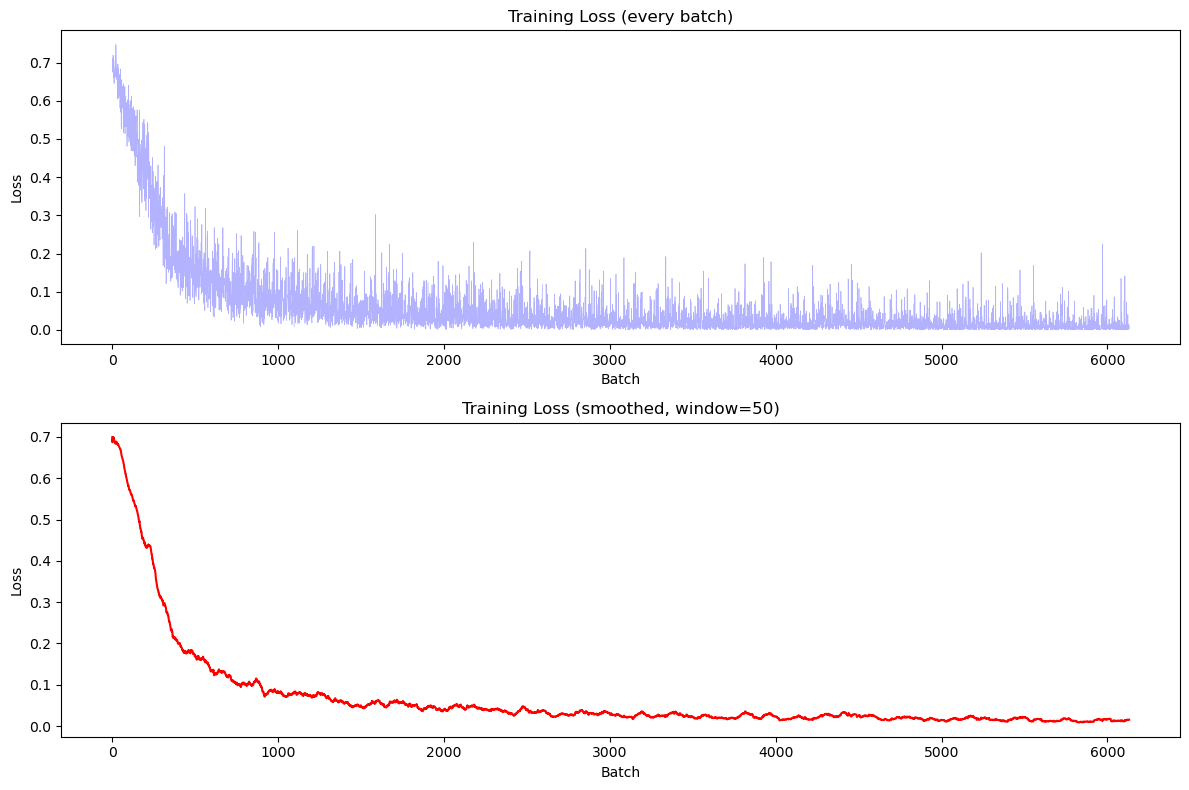

In [16]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

ax1.plot(batch_losses, alpha=0.3, linewidth=0.5, color='blue')
ax1.set_xlabel('Batch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss (every batch)')

window = min(50, len(batch_losses) // 5) if len(batch_losses) > 10 else 1
if window > 1:
    smoothed = []
    for i in range(len(batch_losses)):
        start = max(0, i - window + 1)
        smoothed.append(sum(batch_losses[start:i+1]) / (i - start + 1))
    ax2.plot(smoothed, linewidth=1.5, color='red')
else:
    ax2.plot(batch_losses, linewidth=1.5, color='red')
ax2.set_xlabel('Batch')
ax2.set_ylabel('Loss')
ax2.set_title(f'Training Loss (smoothed, window={window})')

plt.tight_layout()
plt.savefig('batch_losses.png', dpi=150, bbox_inches='tight')
plt.show()

## Plot: Epoch-level Metrics

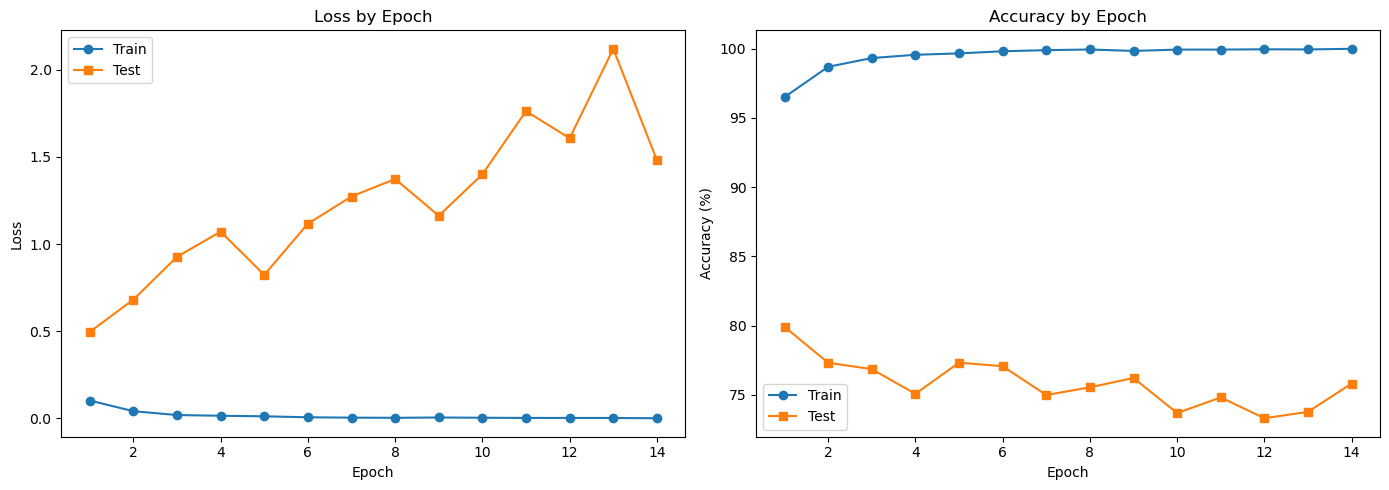

In [17]:
epochs_range = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, train_losses, 'o-', label='Train')
ax1.plot(epochs_range, test_losses, 's-', label='Test')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss by Epoch')
ax1.legend()

ax2.plot(epochs_range, train_accs, 'o-', label='Train')
ax2.plot(epochs_range, test_accs, 's-', label='Test')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy by Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('epoch_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Model

In [18]:
if SAVE_MODEL:
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Model saved to {MODEL_PATH}")

Model saved to ti_cnn.pt
